In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!pip install -q pyspark seaborn

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lit, to_date, month, year, date_format, trim, lower, when
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

spark = SparkSession.builder.appName("CrimeDataset_PartA").getOrCreate()

print("✅ Spark started! Version:", spark.version)

In [ ]:
import os, glob, textwrap, pathlib

base = "/kaggle/input"

print("Contents of /kaggle/input:")

print("\n".join(os.listdir(base)))

In [ ]:
data_root = "/kaggle/input/crime-dataset-ctec3702"



csv_files = glob.glob(f"{data_root}/**/*.csv", recursive=True)

print("CSV files found:", len(csv_files))

csv_files[:5]

In [ ]:
df_raw = (spark.read

          .option("header", True)

          .option("inferSchema", True)

          .csv(f"{data_root}/**/*.csv"))



print("Rows:", df_raw.count())

df_raw.printSchema()

df_raw.show(5, truncate=False)

In [ ]:
df = df_raw

for c in df.columns:

    df = df.withColumnRenamed(c, c.strip().lower().replace(" ", "_"))



# Derive a clean 'county' from the source field

source_col = "reported_by" if "reported_by" in df.columns else ("falls_within" if "falls_within" in df.columns else None)

if source_col is None:

    print("⚠️ Could not find reported_by/falls_within. We'll keep 'county' as Unknown for now.")

    df = df.withColumn("county", lit("Unknown"))

else:

    df = df.withColumn(

        "county",

        when(lower(col(source_col)).contains("derby"), "Derbyshire")

        .when(lower(col(source_col)).contains("leicester"), "Leicestershire")

        .when(lower(col(source_col)).contains("nottingham"), "Nottinghamshire")

        .otherwise("Other")

    )



# Parse month and add helpers

df = (df

      .withColumn("month_dt", to_date(col("month"), "yyyy-MM"))

      .withColumn("year", year(col("month_dt")))

      .withColumn("month_num", month(col("month_dt")))

      .withColumn("year_month", date_format(col("month_dt"), "yyyy-MM"))

     )



# Handle missing values for key fields

for c in ["crime_type", "county", "year_month"]:

    df = df.withColumn(c, when(col(c).isNull(), lit("Unknown")).otherwise(col(c)))



df.cache()

print("✅ Cleaned rows:", df.count())

df.select("county","crime_type","year_month").show(5, truncate=False)

In [ ]:
df.createOrReplaceTempView("crimes")



# 1) Total crimes by county

by_county = spark.sql("""

SELECT county, COUNT(*) AS total_crimes

FROM crimes

WHERE county IN ('Derbyshire','Leicestershire','Nottinghamshire')

GROUP BY county

ORDER BY total_crimes DESC

""")

by_county.show()



# 2) Monthly trend per county

monthly_trend = spark.sql("""

SELECT year_month, county, COUNT(*) AS total_crimes

FROM crimes

WHERE county IN ('Derbyshire','Leicestershire','Nottinghamshire')

GROUP BY year_month, county

ORDER BY year_month ASC, county

""")

monthly_trend.show(6)



# 3) Crime types per county (we'll pick top-6 later for plotting)

crime_types = spark.sql("""

SELECT county, crime_type, COUNT(*) AS cnt

FROM crimes

WHERE county IN ('Derbyshire','Leicestershire','Nottinghamshire')

GROUP BY county, crime_type

ORDER BY county, cnt DESC

""")

crime_types.show(12)

In [ ]:
# Bar chart: Crime type frequency
crime_type_pdf = crime_types.toPandas()

plt.figure(figsize=(10,5))
sns.barplot(x="crime_type", y="cnt", data=crime_type_pdf)
plt.xticks(rotation=45, ha='right')
plt.title("Crime Type Frequency")
plt.xlabel("Crime Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# Line chart: Monthly crime trend per county

monthly_pdf = monthly_trend.toPandas()



plt.figure(figsize=(10,5))



for county in monthly_pdf['county'].unique():

    subset = monthly_pdf[monthly_pdf['county'] == county]

    plt.plot(subset['year_month'], subset['total_crimes'], marker='o', label=county)



plt.xticks(rotation=45)

plt.title("Monthly Crime Trends by County")

plt.xlabel("Year-Month")

plt.ylabel("Total Crimes")

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
# Total crimes by county

total_crimes = spark.sql("""

    SELECT county, COUNT(*) AS total_crimes

    FROM crimes

    WHERE county IN ('Derbyshire','Leicestershire','Nottinghamshire')

    GROUP BY county

    ORDER BY total_crimes DESC

""")

total_crimes.show()



In [ ]:
# Pie chart: total crimes by county

total_crimes_pdf = total_crimes.toPandas()



plt.figure(figsize=(6,6))

plt.pie(total_crimes_pdf['total_crimes'], 

        labels=total_crimes_pdf['county'], 

        autopct='%1.1f%%')

plt.title("Crime Share by County")

plt.show()

In [ ]:
# Save cleaned dataframe for evidence

df.write.mode("overwrite").parquet("/kaggle/working/clean_crime_dataset.parquet")

print("✅ Cleaned dataset saved to /kaggle/working/")

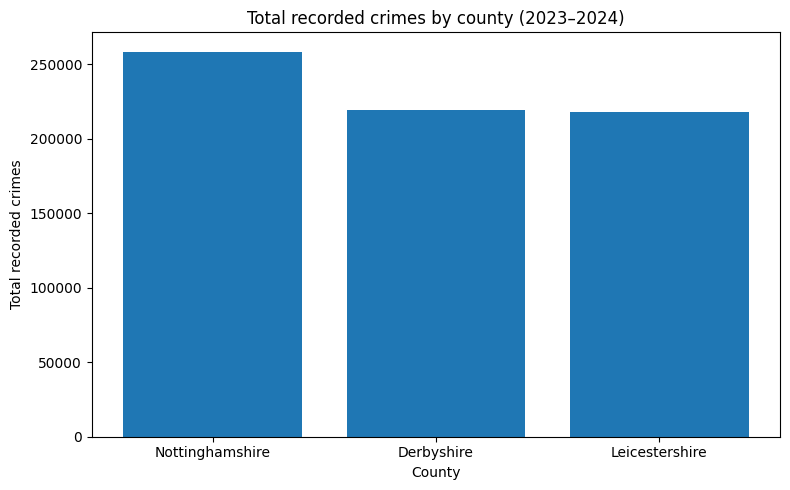

In [7]:
import matplotlib.pyplot as plt

counties = ['Nottinghamshire', 'Derbyshire', 'Leicestershire']
totals = [258417, 219339, 217944]

plt.figure(figsize=(8,5))
plt.bar(counties, totals)
plt.xlabel('County')
plt.ylabel('Total recorded crimes')
plt.title('Total recorded crimes by county (2023–2024)')
plt.tight_layout()
plt.show()

In [8]:
import os

print(os.listdir('/kaggle/input'))

['notebooks', 'crime-dataset-ctec3702']


In [9]:
import os



print(os.listdir('/kaggle/input/crime-dataset-ctec3702'))

['2024-12', '2023-10', '2023-04', '2024-07', '2023-11', '2023-02', '2023-01', '2023-08', '2023-05', '2024-02', '2024-06', '2023-12', '2024-01', '2024-05', '2023-03', '2024-11', '2024-04', '2024-09', '2024-08', '2023-09', '2024-10', '2023-06', '2024-03', '2023-07']


In [10]:
import os

folder = "/kaggle/input/crime-dataset-ctec3702"

print("Folder contents:", os.listdir(folder)[:30])

Folder contents: ['2024-12', '2023-10', '2023-04', '2024-07', '2023-11', '2023-02', '2023-01', '2023-08', '2023-05', '2024-02', '2024-06', '2023-12', '2024-01', '2024-05', '2023-03', '2024-11', '2024-04', '2024-09', '2024-08', '2023-09', '2024-10', '2023-06', '2024-03', '2023-07']


In [11]:
import os

import pandas as pd

import matplotlib.pyplot as plt



base = "/kaggle/input/crime-dataset-ctec3702"



csv_paths = []

for root, dirs, files in os.walk(base):

    for f in files:

        if f.lower().endswith(".csv"):

            csv_paths.append(os.path.join(root, f))



print("Number of CSVs found:", len(csv_paths))

print("Example CSV path:", csv_paths[0] if len(csv_paths) > 0 else "NONE")

Number of CSVs found: 72
Example CSV path: /kaggle/input/crime-dataset-ctec3702/2024-12/2024-12-leicestershire-street.csv


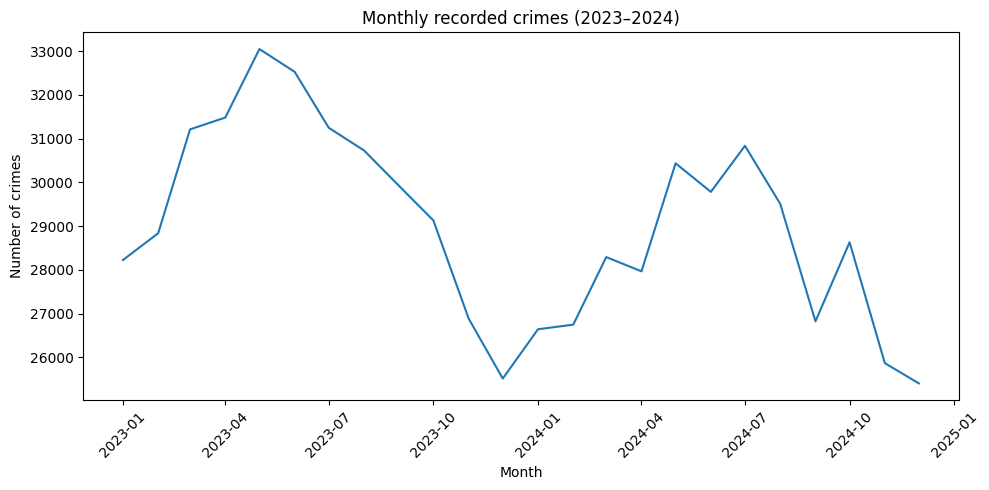

In [12]:
df_list = [pd.read_csv(p) for p in csv_paths]

data = pd.concat(df_list, ignore_index=True)



data["Month"] = pd.to_datetime(data["Month"], errors="coerce")

data = data.dropna(subset=["Month"])



monthly = data.groupby("Month").size().reset_index(name="Crime Count").sort_values("Month")



plt.figure(figsize=(10,5))

plt.plot(monthly["Month"], monthly["Crime Count"])

plt.xlabel("Month")

plt.ylabel("Number of crimes")

plt.title("Monthly recorded crimes (2023–2024)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()



In [13]:
import os



base = "/kaggle/input/crime-dataset-ctec3702"

for root, dirs, files in os.walk(base):

    print(root)

    print("  subfolders:", dirs[:5])

    print("  files:", files[:5])

    print("-"*40)

    break

/kaggle/input/crime-dataset-ctec3702
  subfolders: ['2024-12', '2023-10', '2023-04', '2024-07', '2023-11']
  files: []
----------------------------------------


CSV files found: 72
Example file: /kaggle/input/crime-dataset-ctec3702/2024-12/2024-12-leicestershire-street.csv


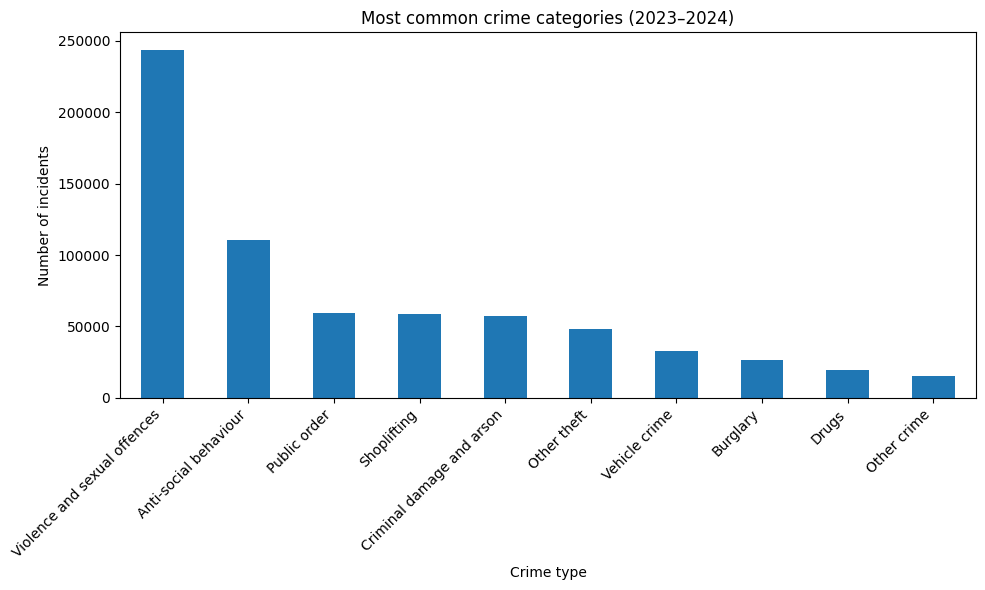

In [14]:
import pandas as pd

import matplotlib.pyplot as plt

import os



base = "/kaggle/input/crime-dataset-ctec3702"



csv_paths = []

for root, dirs, files in os.walk(base):

    for f in files:

        if f.lower().endswith(".csv"):

            csv_paths.append(os.path.join(root, f))



print("CSV files found:", len(csv_paths))

print("Example file:", csv_paths[0] if csv_paths else "NONE")



df_list = [pd.read_csv(p) for p in csv_paths]

data = pd.concat(df_list, ignore_index=True)



crime_types = data["Crime type"].value_counts().head(10)



plt.figure(figsize=(10,6))

crime_types.plot(kind="bar")

plt.title("Most common crime categories (2023–2024)")

plt.xlabel("Crime type")

plt.ylabel("Number of incidents")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()